# Predicting Online Purchase Intention from Web Session Behaviour

This notebook investigates whether e-commerce browsing sessions can be classified as purchase or non-purchase sessions using supervised machine learning.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

RANDOM_STATE = 42

## Initial data examination

In [3]:
df = pd.read_csv("../data/online_shoppers_intention.csv")
df.head(10)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,Feb,2,4,3,3,Returning_Visitor,False,False
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,2,1,5,Returning_Visitor,True,False
8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.0,0.8,Feb,2,2,2,3,Returning_Visitor,False,False
9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.0,0.4,Feb,2,4,1,2,Returning_Visitor,False,False


The first rows show that each record represents one online shopping session. The target variable is `Revenue`, which shows whether the session ended in a purchase.

The input features describe browsing behaviour, timing and visitor/session information. These include page counts, page durations, rates such as `BounceRates` and `ExitRates`, `PageValues`, `Month`, `VisitorType`, `Weekend` and coded technical features such as `Browser`, `Region` and `TrafficType`.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

The `df.info()` output shows that the dataset has 12,330 rows and 18 columns. All columns have 12,330 non-null values, so there are no missing values shown at this stage.

The data contains a mixture of integers, floats, strings and Boolean values. This means preprocessing will be needed before modelling, especially for categorical variables and Boolean values.

In [5]:
summary_checks = pd.DataFrame({
    "rows": [df.shape[0]],
    "columns": [df.shape[1]],
    "duplicate_rows": [df.duplicated().sum()],
    "missing_values_total": [df.isnull().sum().sum()]
})

summary_checks

,rows,columns,duplicate_rows,missing_values_total
0,12330,18,125,0


The dataset has 12,330 rows and 18 columns, with no missing values.

There are 125 duplicate rows. I will not remove them automatically because this is session data, and different sessions may have the same recorded behaviour.

In [6]:
revenue_summary = pd.DataFrame({
    "count": df["Revenue"].value_counts(),
    "percentage": df["Revenue"].value_counts(normalize=True) * 100
})

revenue_summary

,count,percentage
Revenue,,
False,10422,84.525547
True,1908,15.474453


The `Revenue` summary shows a clear class imbalance. Most sessions did not end in a purchase.

This matters because a model could get a decent accuracy by mostly predicting `False`. I will therefore use precision, recall, F1-score and a confusion matrix later, not just accuracy.

Next, I examine the numerical feature distributions to understand the scale and spread of the input variables.

In [7]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


The numerical columns have quite different ranges. For example, duration and page-count columns are much larger than rate columns such as `BounceRates` and `ExitRates`.

This means scaling may be useful later for models such as logistic regression or k-nearest neighbours. Tree-based models are less affected by scaling.

In [8]:
categorical_cols = ["Month", "VisitorType", "Weekend", "OperatingSystems", "Browser", "Region", "TrafficType"]

categorical_summary = pd.DataFrame({
    "unique_values": df[categorical_cols].nunique(),
    "most_common_value": df[categorical_cols].mode().iloc[0],
    "most_common_count": [df[col].value_counts().iloc[0] for col in categorical_cols]
})

categorical_summary

,unique_values,most_common_value,most_common_count
Month,10,May,3364
VisitorType,3,Returning_Visitor,10551
Weekend,2,False,9462
OperatingSystems,8,2,6601
Browser,13,2,7961
Region,9,1,4780
TrafficType,20,2,3913


This table shows the number of unique values in each categorical or coded feature.

These columns will need encoding before modelling, especially `Month`, `VisitorType`, `OperatingSystems`, `Browser`, `Region` and `TrafficType`.

In [9]:
df.groupby("Revenue")[["PageValues", "BounceRates", "ExitRates", "ProductRelated", "ProductRelated_Duration"]].mean()

,PageValues,BounceRates,ExitRates,ProductRelated,ProductRelated_Duration
Revenue,,,,,
False,1.975998,0.025317,0.047378,28.714642,1069.987809
True,27.264518,0.005117,0.019555,48.210168,1876.209615


The grouped averages show clear differences between purchase and non-purchase sessions. Purchase sessions have much higher average `PageValues`, more `ProductRelated` page visits, longer `ProductRelated_Duration`, lower `BounceRates` and lower `ExitRates`.

This suggests that browsing depth and page value may be useful predictors. I will check this later using feature importance and model results.

## Exploratory visualisation

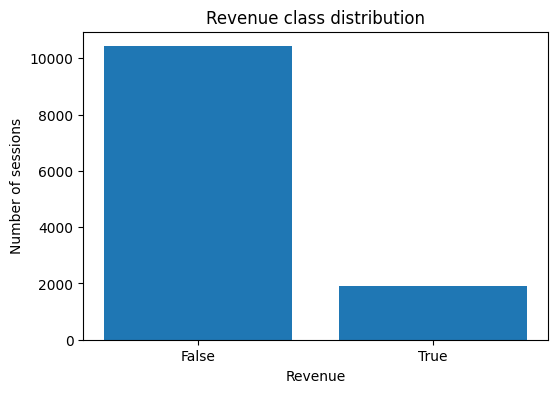

In [10]:
revenue_counts = df["Revenue"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(revenue_counts.index.astype(str), revenue_counts.values)
plt.title("Revenue class distribution")
plt.xlabel("Revenue")
plt.ylabel("Number of sessions")
plt.show()

The chart shows a clear class imbalance. Most sessions did not end in a purchase.

Because of this, accuracy on its own will not be enough. I will also use precision, recall, F1-score and a confusion matrix later.

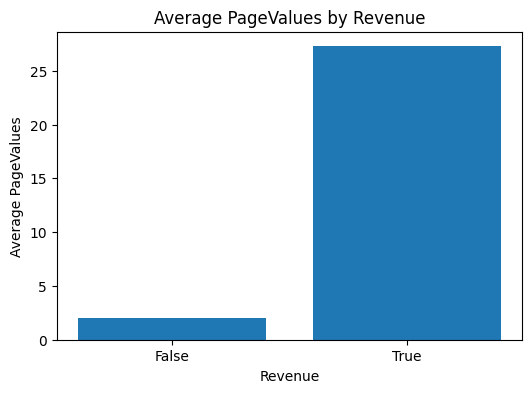

In [11]:
pagevalues_mean = df.groupby("Revenue")["PageValues"].mean()

plt.figure(figsize=(6, 4))
plt.bar(pagevalues_mean.index.astype(str), pagevalues_mean.values)
plt.title("Average PageValues by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Average PageValues")
plt.show()

Purchase sessions have much higher average `PageValues`.

This suggests that `PageValues` may be useful for predicting `Revenue`. I will check this again later when comparing feature importance and model performance.

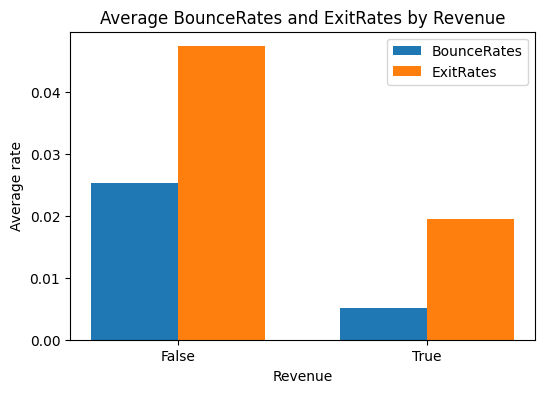

In [12]:
rate_means = df.groupby("Revenue")[["BounceRates", "ExitRates"]].mean()

x = np.arange(len(rate_means.index))
width = 0.35

plt.figure(figsize=(6, 4))
plt.bar(x - width/2, rate_means["BounceRates"], width, label="BounceRates")
plt.bar(x + width/2, rate_means["ExitRates"], width, label="ExitRates")
plt.title("Average BounceRates and ExitRates by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Average rate")
plt.xticks(x, rate_means.index.astype(str))
plt.legend()
plt.show()

Purchase sessions have lower average `BounceRates` and `ExitRates`.

`BounceRates` refers to sessions where a user enters the site and leaves without continuing to other pages. `ExitRates` refers to how often users leave from a particular page. 

Lower values for purchase sessions suggest that users who stay and continue browsing are more likely to buy, so these features may help the models separate purchase and non-purchase sessions.

## Feature and target preparation

In [13]:
# Separate the input features from the target variable
X = df.drop("Revenue", axis=1)
y = df["Revenue"]

print("Feature data shape:", X.shape)
print("Target data shape:", y.shape)

Feature data shape: (12330, 17)
Target data shape: (12330,)


I split the dataset into `X` and `y`. `X` contains the input features, and `y` contains the target variable, `Revenue`.

This gives 17 features for each session and one target value to predict.

In [14]:
# Check the target balance before splitting the data
target_balance = pd.DataFrame({
    "count": y.value_counts(),
    "percentage": y.value_counts(normalize=True) * 100
})

target_balance

,count,percentage
Revenue,,
False,10422,84.525547
True,1908,15.474453


The target balance is checked again before splitting the data.

Because the classes are imbalanced, I will use a stratified train-test split so that the training and test sets keep a similar balance of purchase and non-purchase sessions.

In [ ]:
# Set up the column groups for preprocessing
categorical_features = [
    "Month",
    "VisitorType",
    "Weekend",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType"
]

numerical_features = [col for col in X.columns if col not in categorical_features]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['Month', 'VisitorType', 'Weekend', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

Numerical features:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']


The columns are separated into categorical and numerical features.

The categorical list includes text columns, one Boolean value and coded category columns. The remaining columns are treated as numerical browsing-behaviour features.

In [ ]:
# Split the data with an 80/20 train/test split
# Stratify keeps the Revenue balance similar in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training features:", X_train.shape)
print("Test features:", X_test.shape)
print("Training target:", y_train.shape)
print("Test target:", y_test.shape)

Training features: (9864, 17)
Test features: (2466, 17)
Training target: (9864,)
Test target: (2466,)


The data is split into training and test sets. The training set will be used to fit the models, while the test set will be kept back for evaluation.

I used an 80/20 split because the dataset is large enough to leave a useful test set while still keeping most of the data for training.

In [21]:
# Check that the class balance is similar after the split
split_balance = pd.DataFrame({
    "train_percentage": y_train.value_counts(normalize=True) * 100,
    "test_percentage": y_test.value_counts(normalize=True) * 100
})

split_balance

,train_percentage,test_percentage
Revenue,,
False,84.529603,84.509327
True,15.470397,15.490673


`split_balance` confirms that stratification successfully maintained consistent class proportions between the training and testing sets.

In [ ]:
# Preprocessing setup
# Scale numbers and one-hot encode categories
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print(preprocessor)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Administrative', 'Administrative_Duration',
                                  'Informational', 'Informational_Duration',
                                  'ProductRelated', 'ProductRelated_Duration',
                                  'BounceRates', 'ExitRates', 'PageValues',
                                  'SpecialDay']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Month', 'VisitorType', 'Weekend',
                                  'OperatingSystems', 'Browser', 'Region',
                                  'TrafficType'])])


The preprocessor applies different steps to different column types.

The numerical columns are scaled with `StandardScaler`, and the categorical columns are converted with `OneHotEncoder`. This prepares the data for models that need numerical input.

## Candidate model choices

At this stage I want to try a few different classification models and see what happens, rather than deciding too early.

I am starting with logistic regression because it is one of the basic models and gives me a simple baseline. If this performs reasonably well, it would suggest that some of the patterns in the data are quite straightforward.

I also want to try a decision tree because it feels suitable for this dataset. The data has features like PageValues, ExitRates and ProductRelated duration, so it makes sense that a tree might be able to split the sessions into useful groups.

Random forest is worth trying because it is basically a stronger version of decision trees. It may perform better than one tree and it can also show feature importance, which will be useful later for the report.

I want to try k-nearest neighbours because it is a standard classification method from the labs, and it gives me another type of model to compare. Since it uses distances between rows, it also links back to why scaling the data matters.

Support vector machine is another standard classifier I want to test. I do not know yet whether it will be one of the best models here, but it is a useful comparison because it works differently from trees and logistic regression.

I have also looked into models that are often used for tabular data, so I want to try gradient boosting as well. I have not used it much before, but it may be good here because the earlier analysis showed differences between purchase and non-purchase sessions that may not be completely linear.

Finally, I want to try MLPClassifier as a simple neural network option. I am not going into more complex neural networks like LSTM because this dataset is not really a click-by-click sequence. Each row is already a summary of a session, so a normal classifier or a simple MLP seems more suitable.


## Baseline model comparison

I will now try several baseline classification models using the same train-test split and the same preprocessing steps.

Because the target is imbalanced, accuracy could be misleading. I will still record accuracy, but I will focus more on F1-score, recall, precision and the confusion matrix.

In [45]:
# Baseline models to try first
# class_weight="balanced" gives more weight to the minority class
# This may help because there are fewer purchase sessions than non-purchase sessions
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "K-Nearest Neighbours": KNeighborsClassifier(),
    "Support Vector Machine": SVC(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
    "MLPClassifier": MLPClassifier(
        max_iter=500,
        random_state=RANDOM_STATE
    )
}

In [46]:
def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    # Put the same preprocessing in front of every model
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train on the training data only
    pipeline.fit(X_train, y_train)
    
    # Predict on the test data
    y_pred = pipeline.predict(X_test)
    
    # Store the main scores
    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, pos_label=True, zero_division=0),
        "recall": recall_score(y_test, y_pred, pos_label=True, zero_division=0),
        "f1": f1_score(y_test, y_pred, pos_label=True, zero_division=0)
    }
    
    print("\n" + model_name)
    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    return results, pipeline

In [47]:
baseline_results = []
trained_pipelines = {}

for model_name, model in models.items():
    results, pipeline = evaluate_model(
        model_name,
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )
    
    baseline_results.append(results)
    trained_pipelines[model_name] = pipeline


Logistic Regression
Confusion matrix:
[[1790  294]
 [  98  284]]

Classification report:
              precision    recall  f1-score   support

       False       0.95      0.86      0.90      2084
        True       0.49      0.74      0.59       382

    accuracy                           0.84      2466
   macro avg       0.72      0.80      0.75      2466
weighted avg       0.88      0.84      0.85      2466


Decision Tree
Confusion matrix:
[[1900  184]
 [ 188  194]]

Classification report:
              precision    recall  f1-score   support

       False       0.91      0.91      0.91      2084
        True       0.51      0.51      0.51       382

    accuracy                           0.85      2466
   macro avg       0.71      0.71      0.71      2466
weighted avg       0.85      0.85      0.85      2466


Random Forest
Confusion matrix:
[[2028   56]
 [ 206  176]]

Classification report:
              precision    recall  f1-score   support

       False       0.91      0.97

/Users/garyzolty/Desktop/University/AML/aml-online-shoppers/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [48]:
baseline_results_df = pd.DataFrame(baseline_results)

baseline_results_df.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1
5,Gradient Boosting,0.899027,0.709779,0.589005,0.643777
4,Support Vector Machine,0.865369,0.547710,0.751309,0.633554
0,Logistic Regression,0.841038,0.491349,0.743455,0.591667
2,Random Forest,0.893755,0.758621,0.460733,0.573290
6,MLPClassifier,0.869424,0.585227,0.539267,0.561308
1,Decision Tree,0.849148,0.513228,0.507853,0.510526
3,K-Nearest Neighbours,0.876723,0.682243,0.382199,0.489933


The baseline comparison shows that the models behave quite differently on the purchase class.

Gradient Boosting has the best F1-score for the `True` class, at about 0.64, and the highest accuracy at about 0.90. Its precision is about 0.71 and recall is about 0.59, so it gives the strongest overall balance in the baseline comparison.

Support Vector Machine has the highest recall for the purchase class, at about 0.75, which means it finds the most actual purchase sessions. However, its precision is lower than Gradient Boosting, so it also makes more false purchase predictions.

Random Forest has the highest precision for the purchase class, at about 0.76, but recall is much lower at about 0.46. This means it gives fewer false purchase predictions, but misses more real purchases.

Logistic Regression remains a useful baseline due to it's good recall, but its precision is lower. Decision Tree and K-Nearest Neighbours are weaker overall on F1-score. MLPClassifier performs reasonably, but it gives a convergence warning, so it needs more tuning before being judged properly.

Based on this first comparison, Gradient Boosting, Support Vector Machine, Random Forest and Logistic Regression look most worth continuing with. Gradient Boosting has the best F1-score, SVM and Logistic Regression have strong recall, and Random Forest has strong precision.
MLPClassifier gives a reasonable result, but it does not outperform the stronger classical models at this stage. It also gives a convergence warning, meaning the training had not fully settled within the maximum number of iterations. I will keep it as an experimental neural network comparison, but I will not make it the main focus unless tuning shows a clear improvement.

## Feature Importance Analysis

I want to look at feature importance before tuning, because it helps show which inputs the strongest baseline model is using most.

This may help decide whether a smaller feature set is worth testing later, but I will not remove features automatically just because they have lower importance.

I will plot the feature importance from Gradient Boosting, which was the strongest baseline model by F1-score. This gives a clearer view of which features are driving the model.

In [50]:
# Get the trained Gradient Boosting pipeline
gb_pipeline = trained_pipelines["Gradient Boosting"]

# Get the fitted model and the fitted preprocessor
gb_model = gb_pipeline.named_steps["model"]
gb_preprocessor = gb_pipeline.named_steps["preprocessor"]

# Get the feature names after preprocessing
feature_names = gb_preprocessor.get_feature_names_out()

# Match each feature name with its importance score
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": gb_model.feature_importances_
})

feature_importance.sort_values(by="importance", ascending=False).head(10)

,feature,importance
8,num__PageValues,0.761722
6,num__BounceRates,0.039888
17,cat__Month_Nov,0.037869
0,num__Administrative,0.030949
7,num__ExitRates,0.029149
5,num__ProductRelated_Duration,0.027533
4,num__ProductRelated,0.023145
1,num__Administrative_Duration,0.011746
16,cat__Month_May,0.008686
3,num__Informational_Duration,0.004747


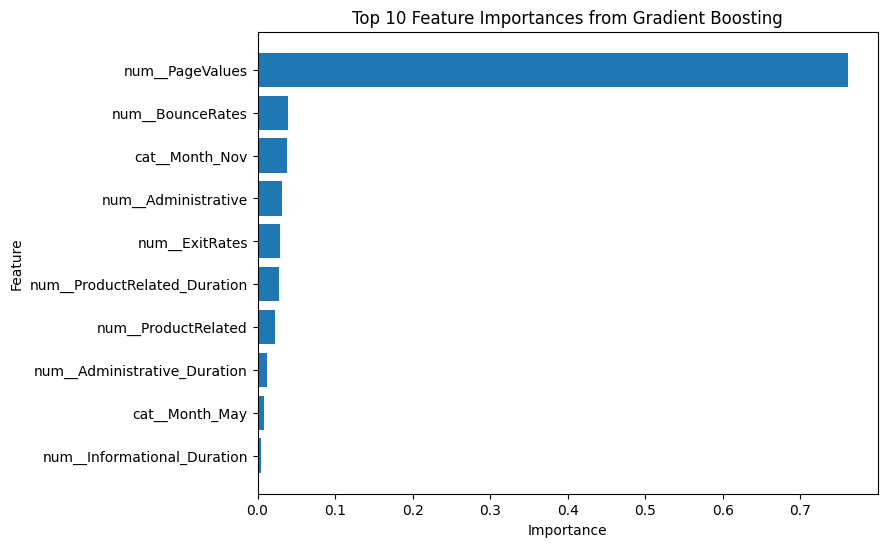

In [51]:
top_features = feature_importance.sort_values(by="importance", ascending=False).head(10)

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])
plt.title("Top 10 Feature Importances from Gradient Boosting")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

The feature importance plot shows that `PageValues` is by far the strongest feature in the Gradient Boosting model.

After `PageValues`, the next most important features are `BounceRates`, `Month_Nov`, `Administrative`, `ExitRates`, `ProductRelated_Duration` and `ProductRelated`. This partly supports the earlier analysis, because `BounceRates`, `ExitRates` and product-related activity all relate to how users move through the website.

`Month_Nov` being important may make sense because online shopping behaviour can change by month, especially around seasonal shopping periods. `Administrative` is also useful to note because it suggests that non-product browsing activity may still contain some signal.

One thing to note is that `PageValues` dominates the plot. I will keep it in the model because it is part of the dataset, but I should mention in the report that the model relies heavily on this feature.